**DATA LOADING AND DATASET UNDERSTANDING**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, pearsonr

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)
print("=" * 70)
print(" DATASET UNDERSTANDING")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe().T)
print("\nCategorical Columns:")
display(df.select_dtypes(include="object").nunique())


 DATASET UNDERSTANDING

Dataset Shape:
(4000, 28)

First 5 Records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-nu

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00



Categorical Columns:


,0
Farm_ID,4000
State,8
District,10
Crop,8
Season,3
Irrigation_Method,4


**DATA QUALITY AND CLEANING**


DATA QUALITY AND CLEANING

Missing Values Before Cleaning:


,Column,Missing Values
6,Rainfall_mm,48
11,Soil_Moisture_pct,40
19,Yield_Tonnes_Ha,32


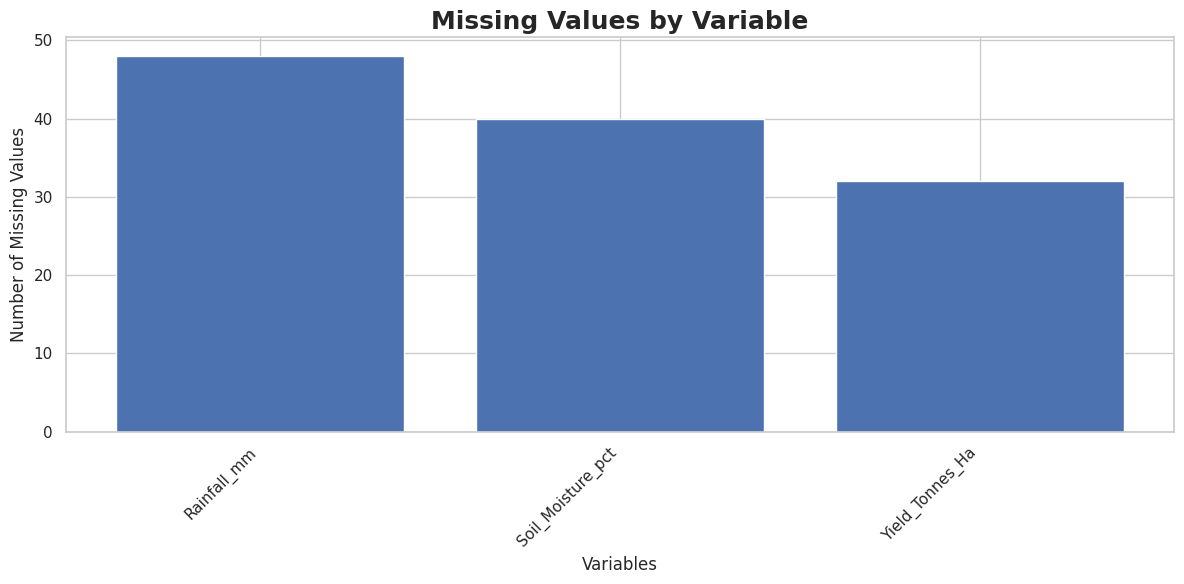

In [28]:
print("\n" + "=" * 70)
print("DATA QUALITY AND CLEANING")
print("=" * 70)

print("\nMissing Values Before Cleaning:")

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_df = missing_df[
    missing_df["Missing Values"] > 0
]
display(missing_df)


# Missing value visualization
plt.figure(figsize=(12, 6))

missing_positive = missing[missing > 0]

plt.bar(
    missing_positive.index,
    missing_positive.values
)

plt.title(
    "Missing Values by Variable",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Variables")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [5]:
# Duplicate analysis
duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)


# Cleaning
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
               )

categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("\nCleaning completed.")

print(
    "Remaining missing values:",
    df_clean.isnull().sum().sum()
)
print(
    "Rows after cleaning:",
    len(df_clean)
)


Duplicate Records: 0

Cleaning completed.
Remaining missing values: 0
Rows after cleaning: 4000



 SEASONAL DISTRIBUTION


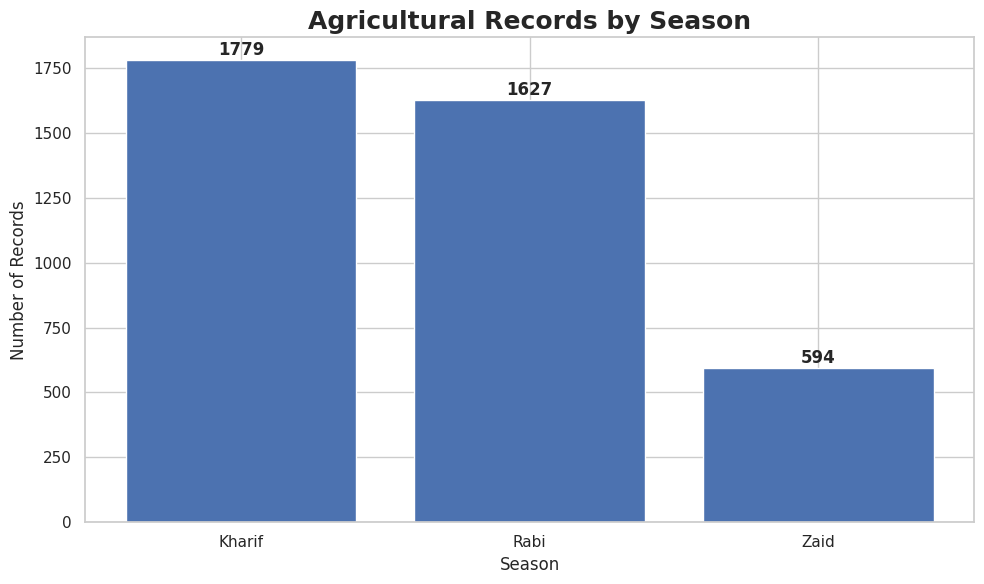

In [29]:
print("\n" + "=" * 70)
print(" SEASONAL DISTRIBUTION")
print("=" * 70)

season_order = [
    "Kharif",
    "Rabi",
    "Zaid"
]

season_counts = (
    df_clean["Season"]
    .value_counts()
    .reindex(season_order)
)
plt.figure(figsize=(10, 6))

bars = plt.bar(
    season_counts.index,
    season_counts.values
)

for bar, value in zip(
    bars,
    season_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Agricultural Records by Season",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

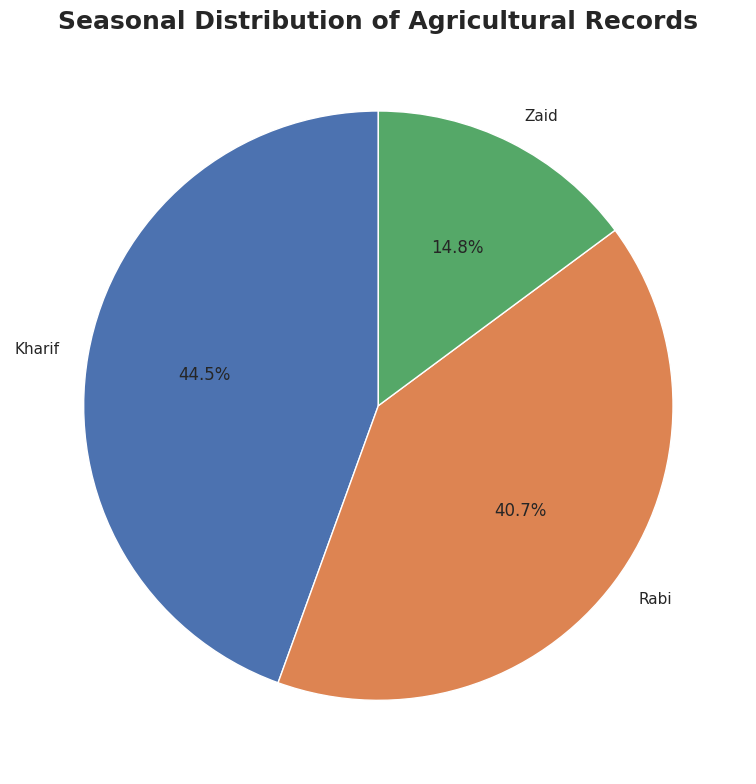

In [8]:
plt.figure(figsize=(8, 8))

plt.pie(
    season_counts.values,
    labels=season_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Seasonal Distribution of Agricultural Records",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



**SEASONAL YIELD ANALYSIS**

In [30]:
print("\n" + "=" * 70)
print(" SEASONAL YIELD ANALYSIS")
print("=" * 70)

season_yield = (
    df_clean.groupby("Season")
    ["Yield_Tonnes_Ha"]
    .mean()
    .reindex(season_order)
)

print("\nAverage Yield:")
display(season_yield.round(2).to_frame("Average Yield"))



 SEASONAL YIELD ANALYSIS

Average Yield:


,Average Yield
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


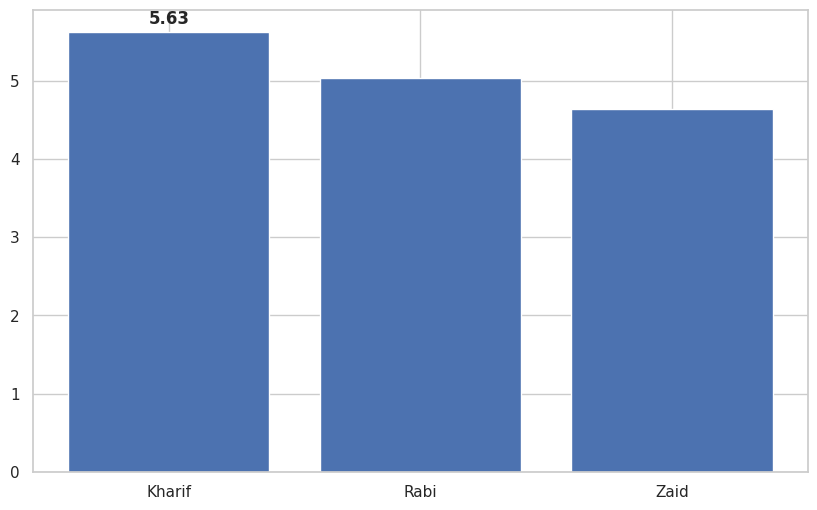

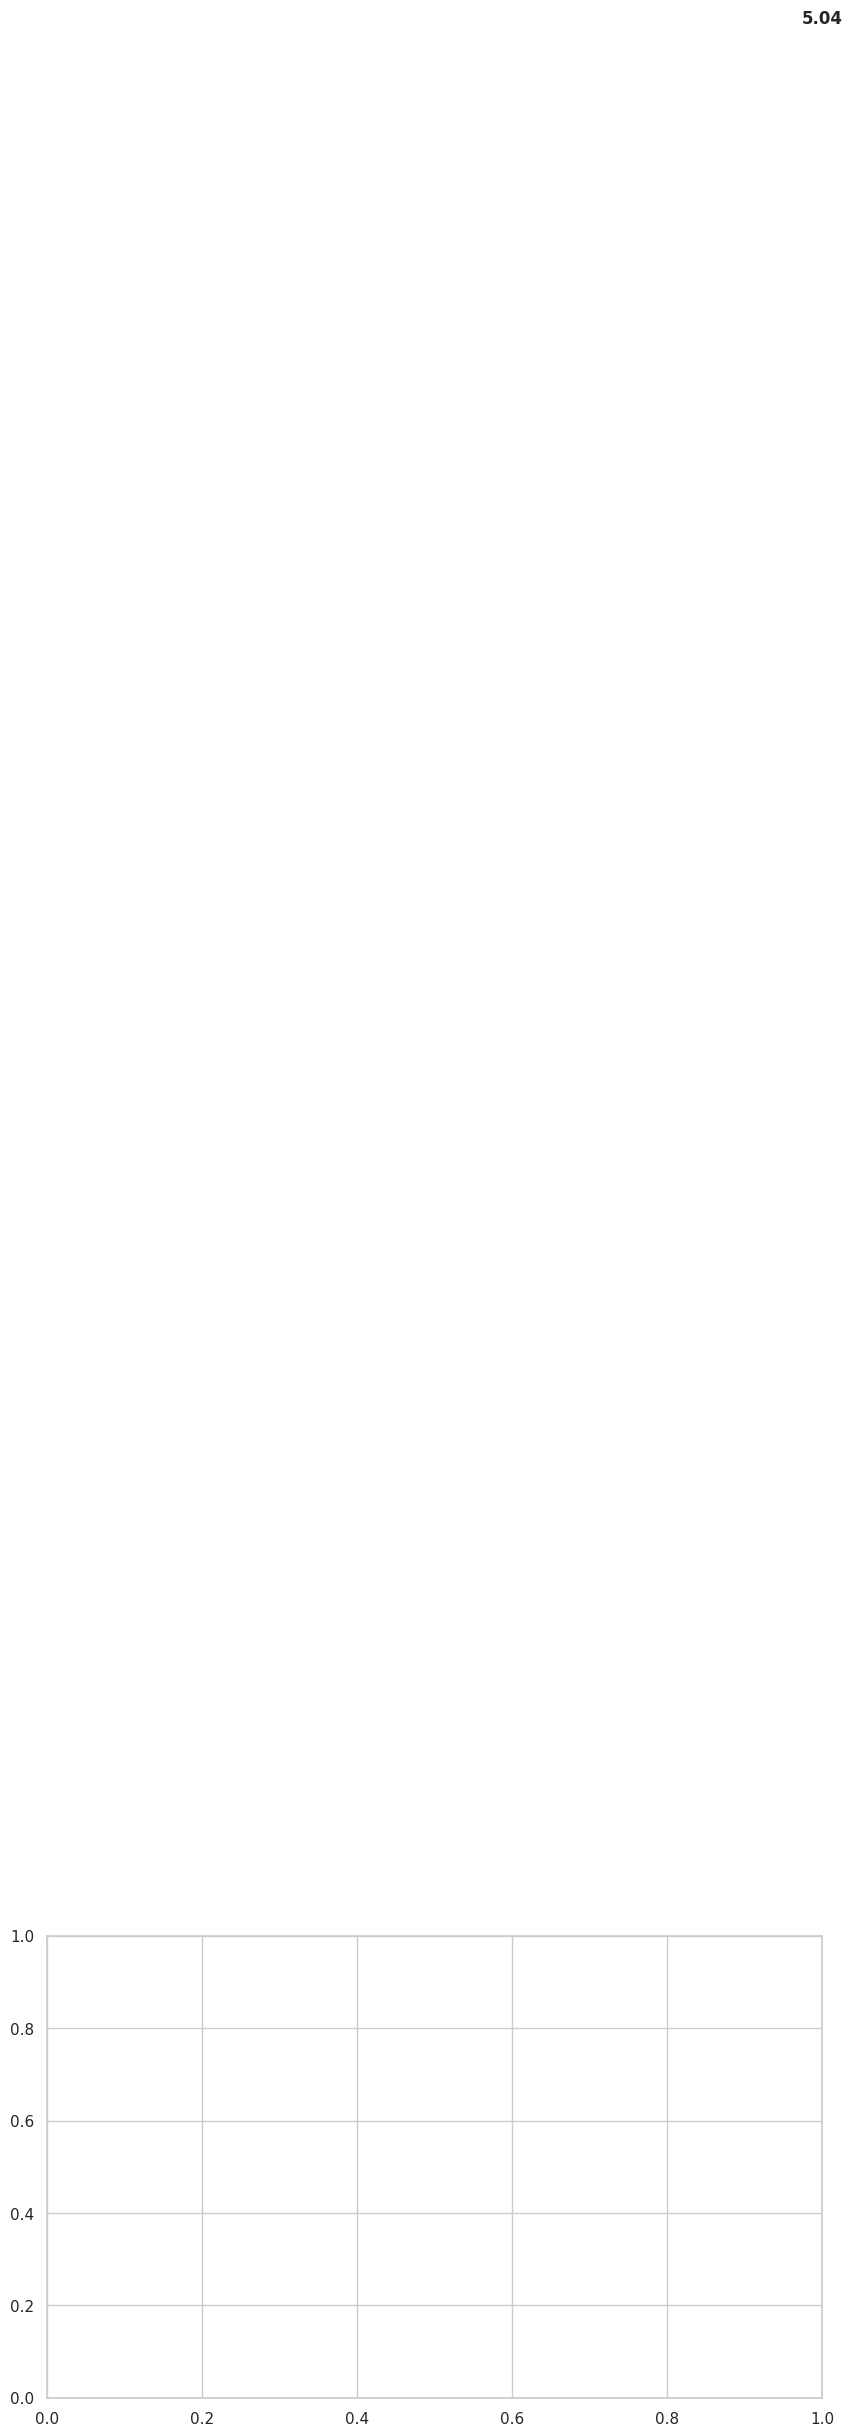

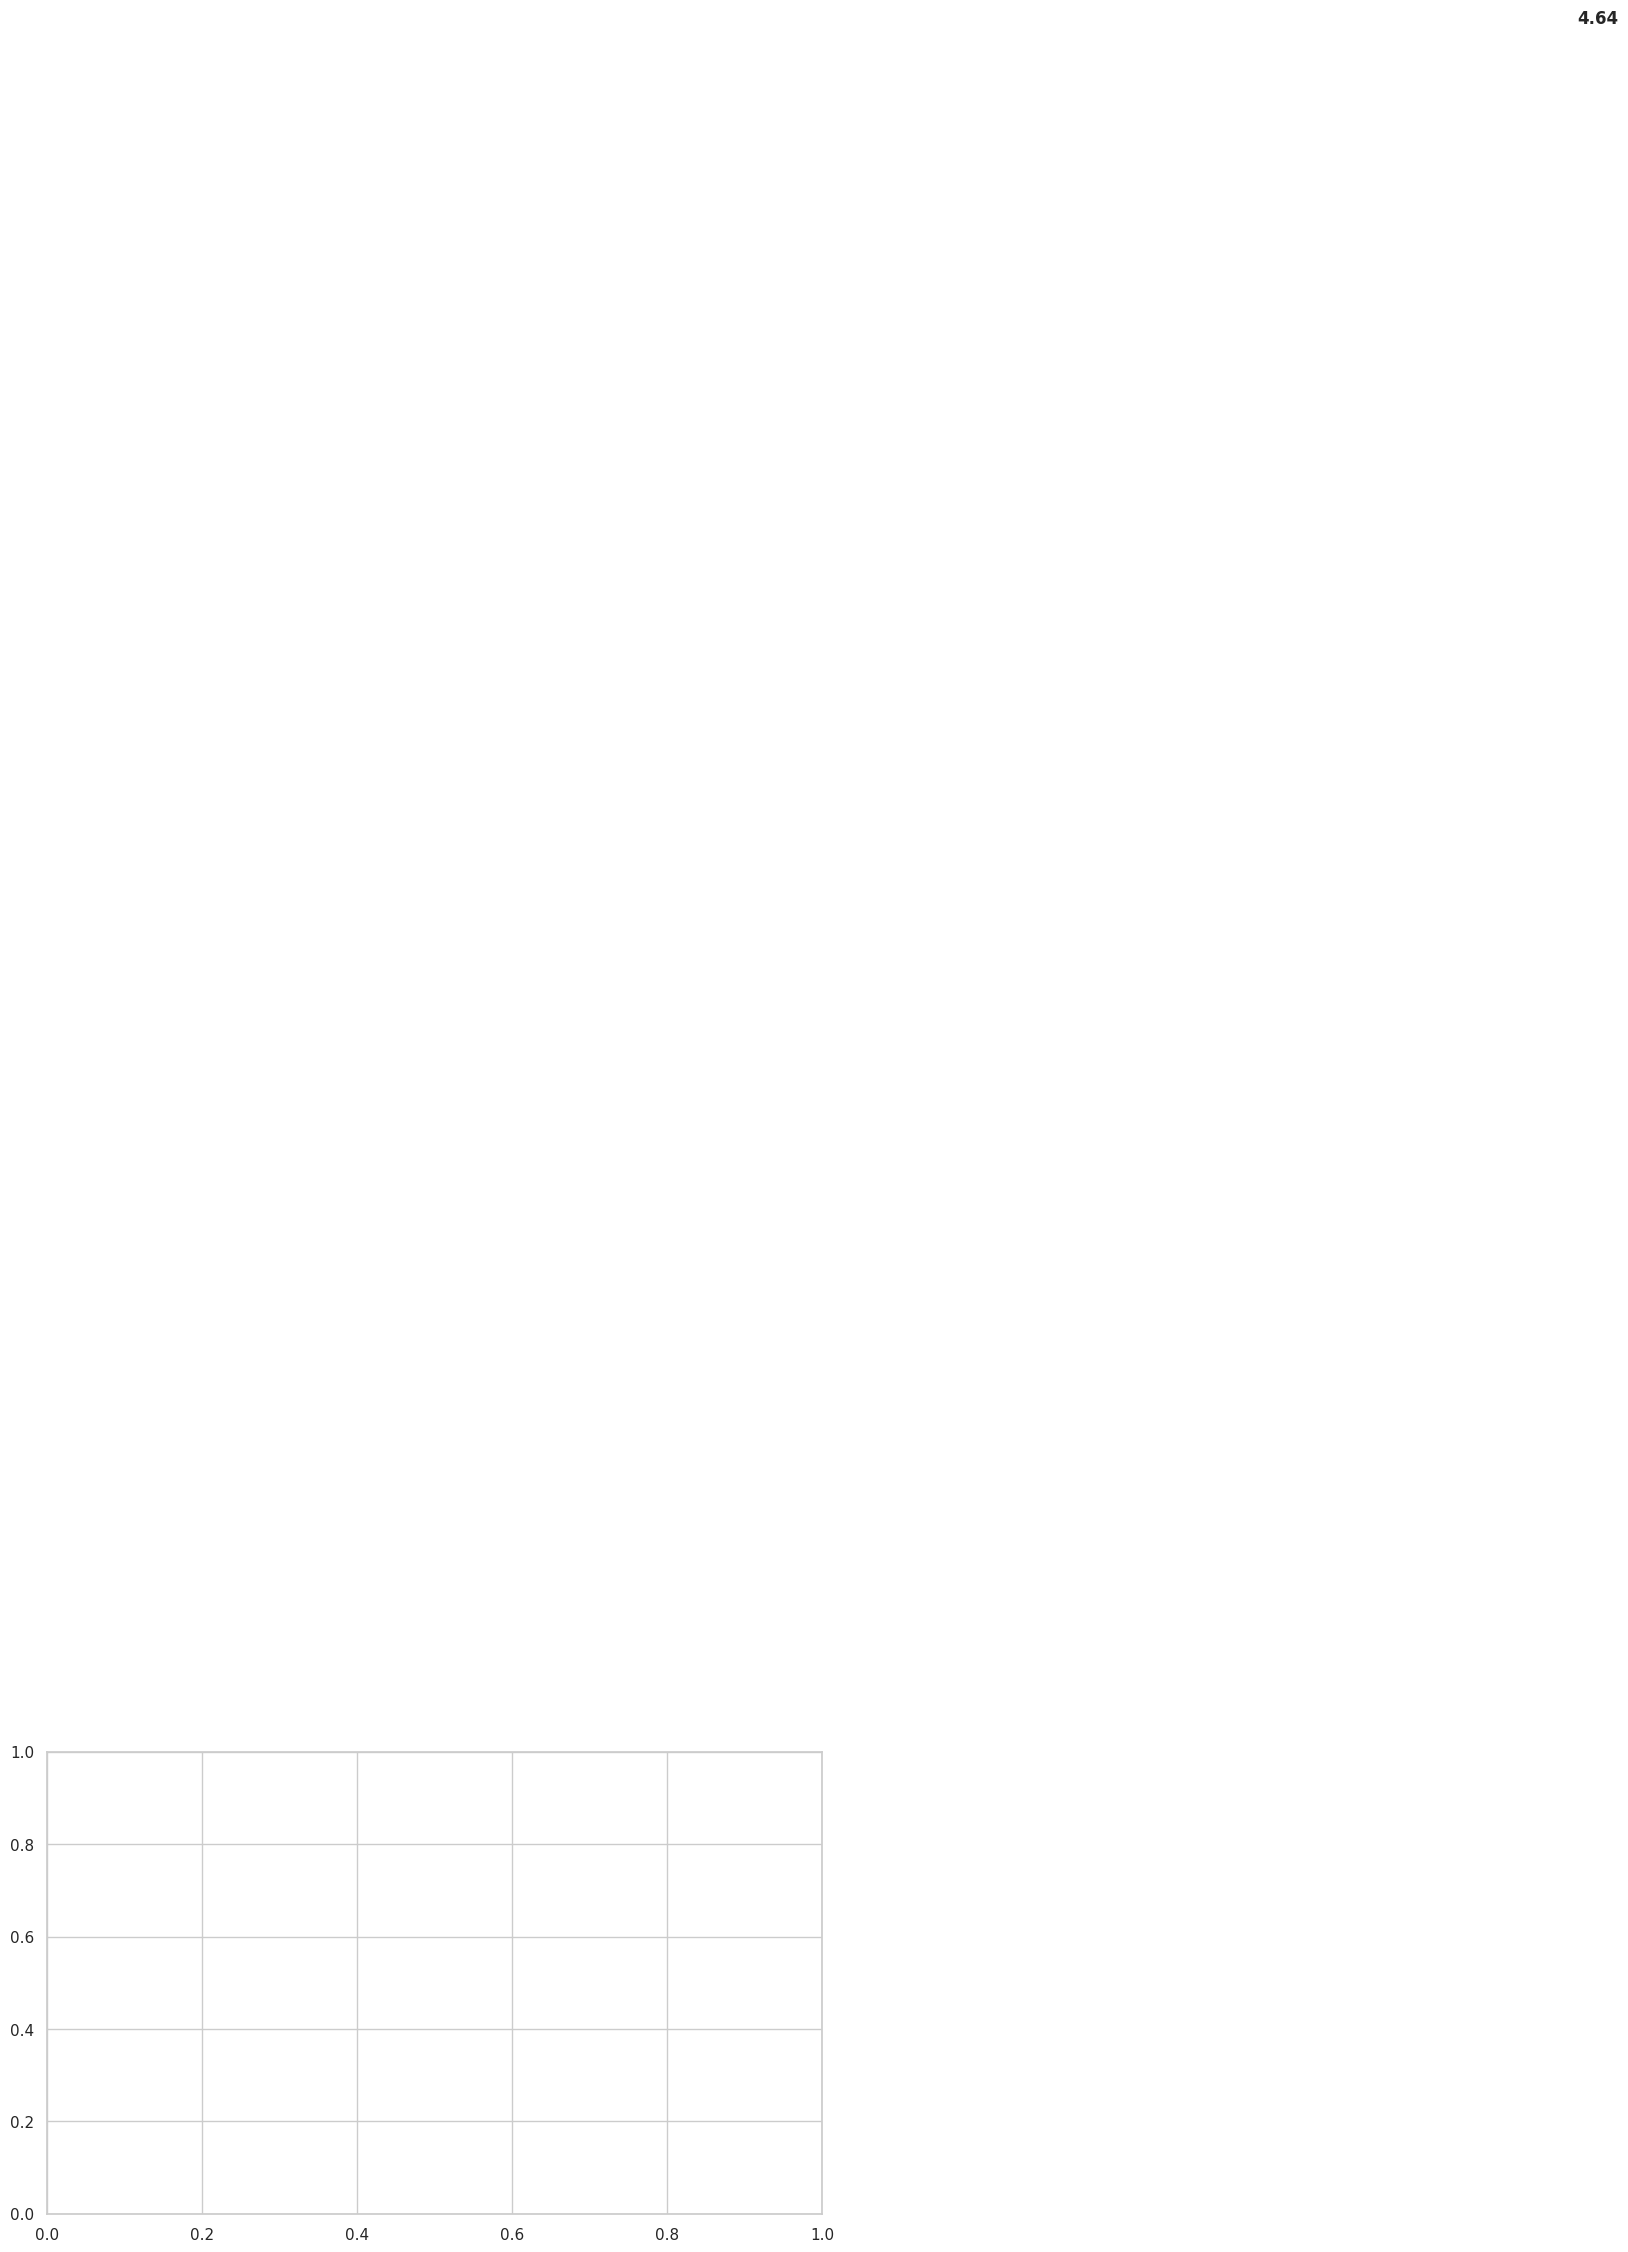

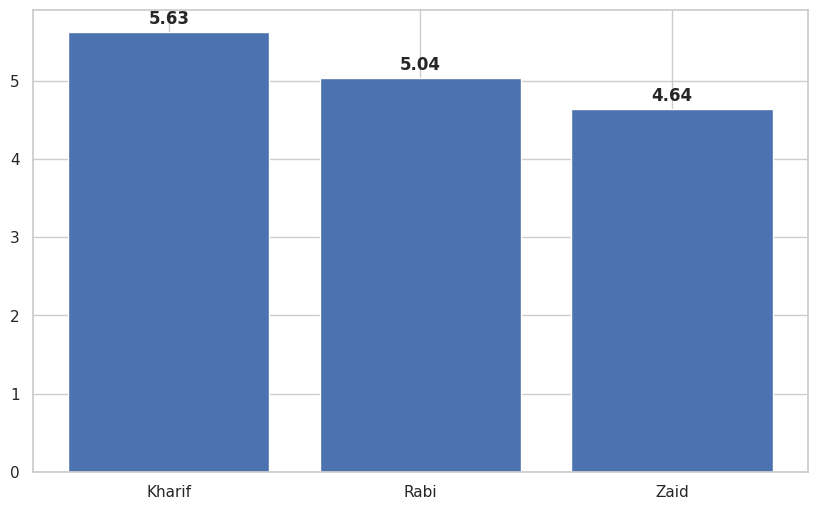

In [10]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    season_yield.index,
    season_yield.values
)

for bar, value in zip(
    bars,
    season_yield.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )
    plt.figure(figsize=(10, 6))

bars = plt.bar(
    season_yield.index,
    season_yield.values
)

for bar, value in zip(
    bars,
    season_yield.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

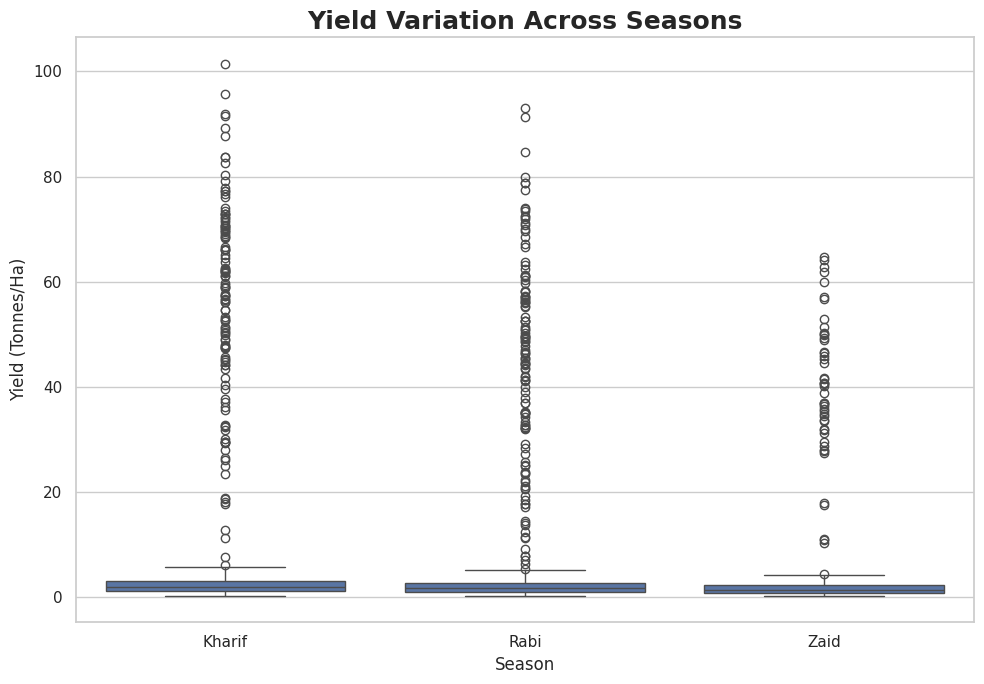

In [11]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order
)

plt.title(
    "Yield Variation Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

****

**PRODUCTION ANALYSIS**


PRODUCTION ANALYSIS


,Average Production
Season,
Kharif,46.31
Rabi,41.49
Zaid,38.89


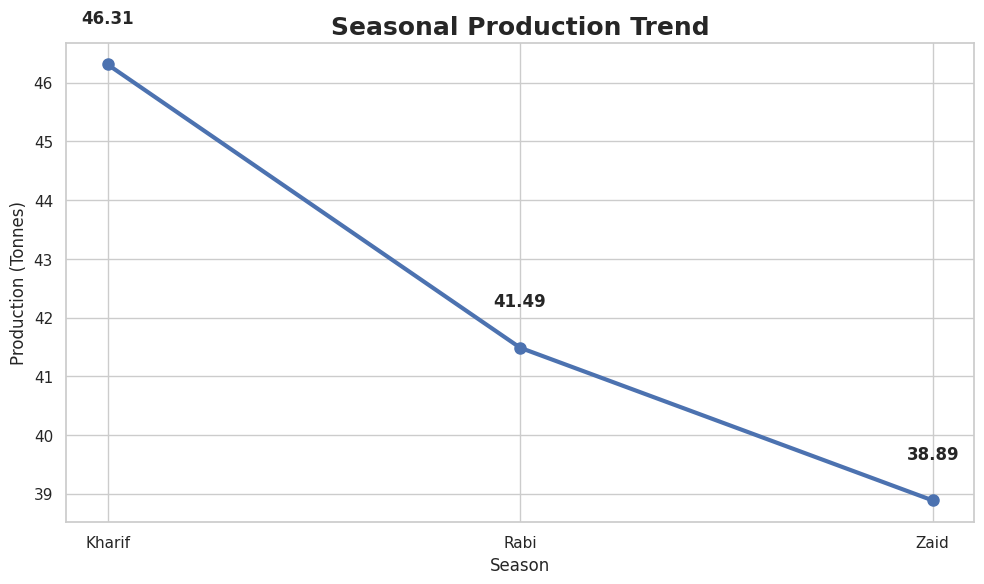

In [31]:
print("\n" + "=" * 70)
print("PRODUCTION ANALYSIS")
print("=" * 70)

production = (
    df_clean.groupby("Season")
    ["Production_Tonnes"]
    .mean()
    .reindex(season_order)
)

display(
    production.round(2).to_frame(
        "Average Production"
    )
)
plt.figure(figsize=(10, 6))

plt.plot(
    production.index,
    production.values,
    marker="o",
    linewidth=3,
    markersize=8
)

for i, value in enumerate(production.values):
    plt.text(
        i,
        value + 0.7,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )
plt.title(
    "Seasonal Production Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()



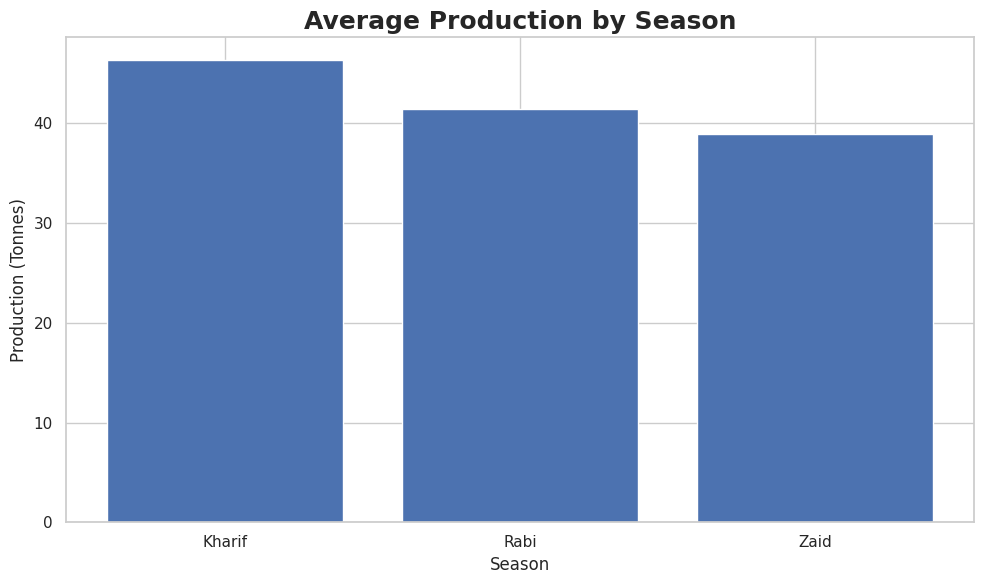

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    production.index,
    production.values
)

plt.title(
    "Average Production by Season",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

**ECONOMIC PERFORMANCE**


 ECONOMIC PERFORMANCE


,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


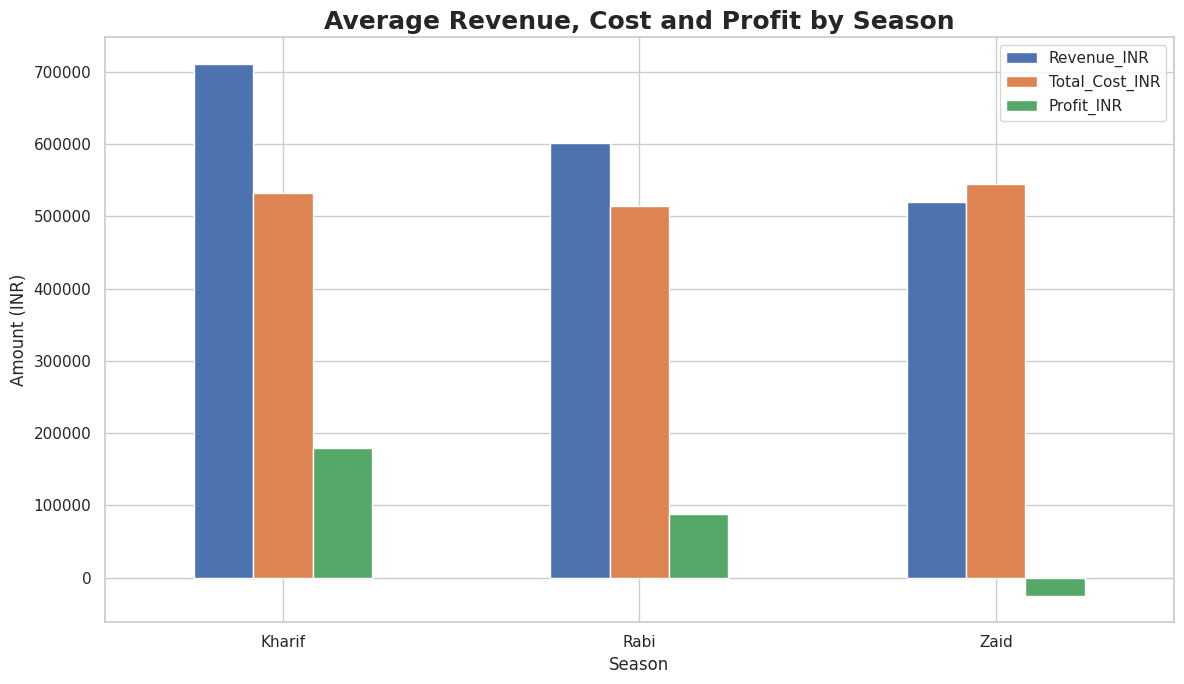

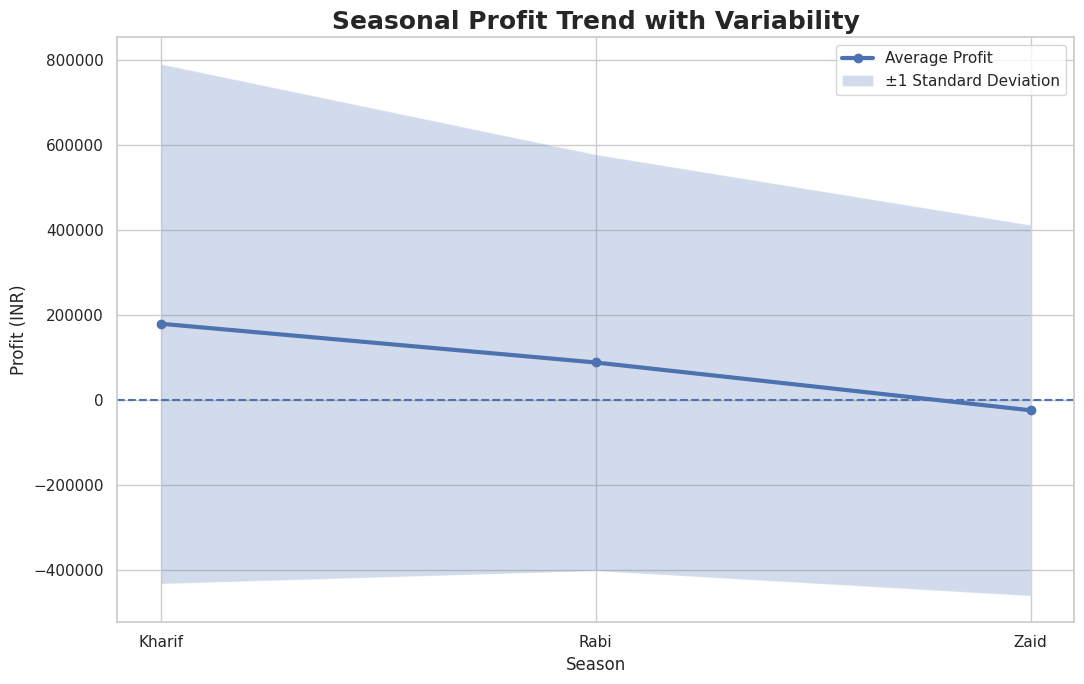

In [32]:
print("\n" + "=" * 70)
print(" ECONOMIC PERFORMANCE")
print("=" * 70)

financial = (
    df_clean.groupby("Season")[
        [
            "Revenue_INR",
            "Total_Cost_INR",
            "Profit_INR"
        ]
    ]
    .mean()
    .reindex(season_order)
)

display(financial.round(2))
financial.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Average Revenue, Cost and Profit by Season",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Amount (INR)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
profit_mean = (
    df_clean.groupby("Season")
    ["Profit_INR"]
    .mean()
    .reindex(season_order)
)

profit_std = (
    df_clean.groupby("Season")
    ["Profit_INR"]
    .std()
    .reindex(season_order)
)

x = np.arange(len(season_order))

plt.figure(figsize=(11, 7))
plt.plot(
    x,
    profit_mean.values,
    marker="o",
    linewidth=3,
    label="Average Profit"
)

plt.fill_between(
    x,
    profit_mean.values - profit_std.values,
    profit_mean.values + profit_std.values,
    alpha=0.25,
    label="±1 Standard Deviation"
)

plt.xticks(
    x,
    season_order
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Seasonal Profit Trend with Variability",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.legend()

plt.tight_layout()
plt.show()

**RESOURCE UTILIZATION**


 RESOURCE UTILIZATION


,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,6102.20,187.08,5.08
Rabi,5846.99,185.41,5.02
Zaid,6419.89,184.64,5.17


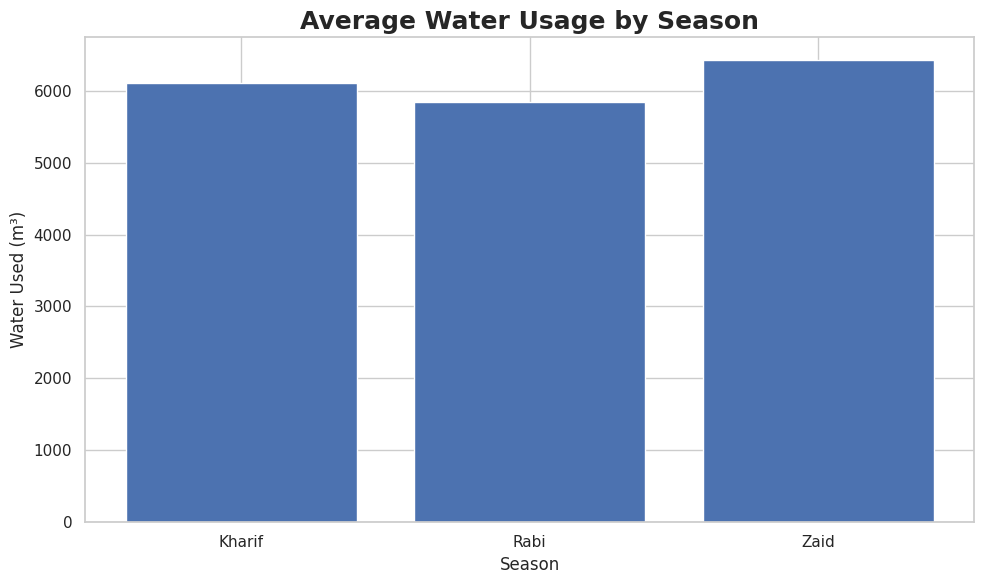

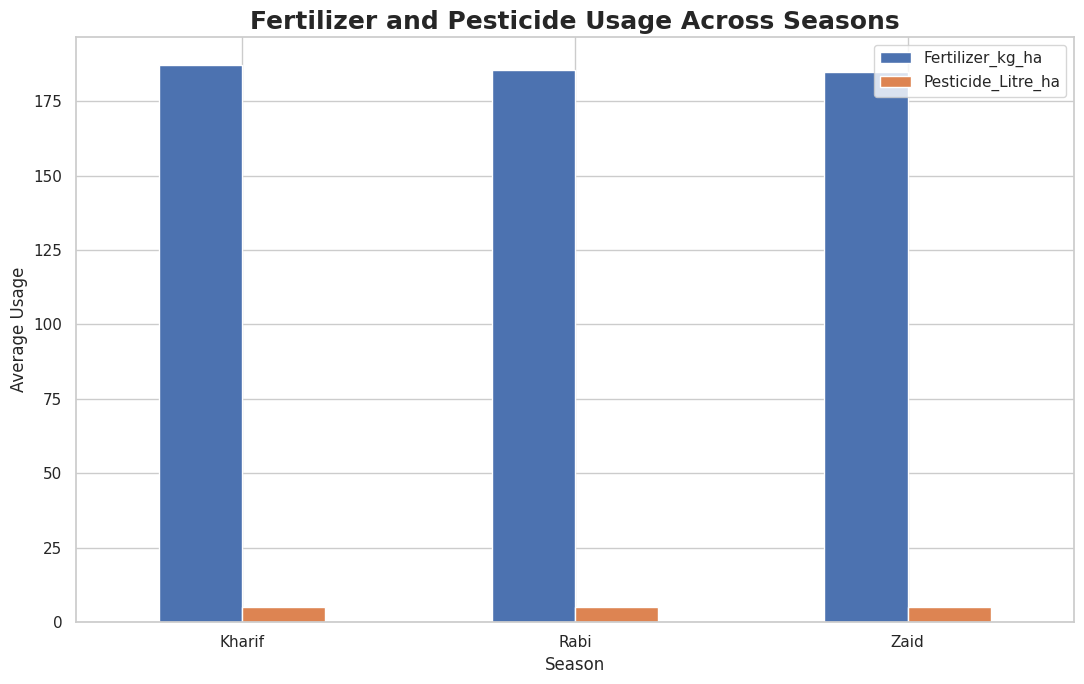

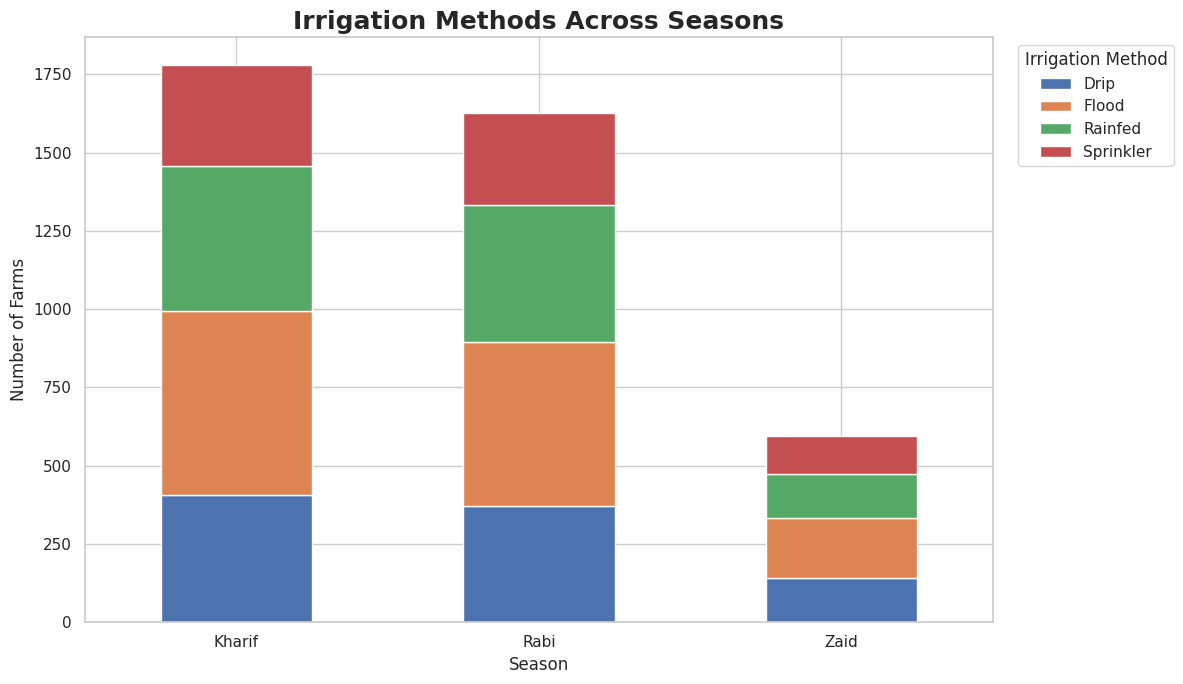

In [33]:
print("\n" + "=" * 70)
print(" RESOURCE UTILIZATION")
print("=" * 70)

resources = (
    df_clean.groupby("Season")[
        [
            "Water_Used_m3",
            "Fertilizer_kg_ha",
            "Pesticide_Litre_ha"
        ]
    ]
    .mean()
    .reindex(season_order)
)

display(resources.round(2))
plt.figure(figsize=(10, 6))

plt.bar(
    resources.index,
    resources["Water_Used_m3"]
)

plt.title(
    "Average Water Usage by Season",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()
resource_plot = resources[
    [
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha"
    ]
]

resource_plot.plot(
    kind="bar",
    figsize=(11, 7)
)

plt.title(
    "Fertilizer and Pesticide Usage Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Average Usage")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# IRRIGATION STACKED BAR
irrigation = pd.crosstab(
    df_clean["Season"],
    df_clean["Irrigation_Method"]
)

irrigation = irrigation.reindex(
    season_order
)

irrigation.plot(
    kind="bar",
    stacked=True,
      figsize=(12, 7)
)

plt.title(
    "Irrigation Methods Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.xticks(rotation=0)

plt.legend(
    title="Irrigation Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


**ENVIRONMENTAL CONDITIONS**


 ENVIRONMENTAL CONDITIONS


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,849.20,28.45,71.81,6.79
Rabi,437.62,23.49,57.89,7.59
Zaid,304.65,31.04,52.01,8.18


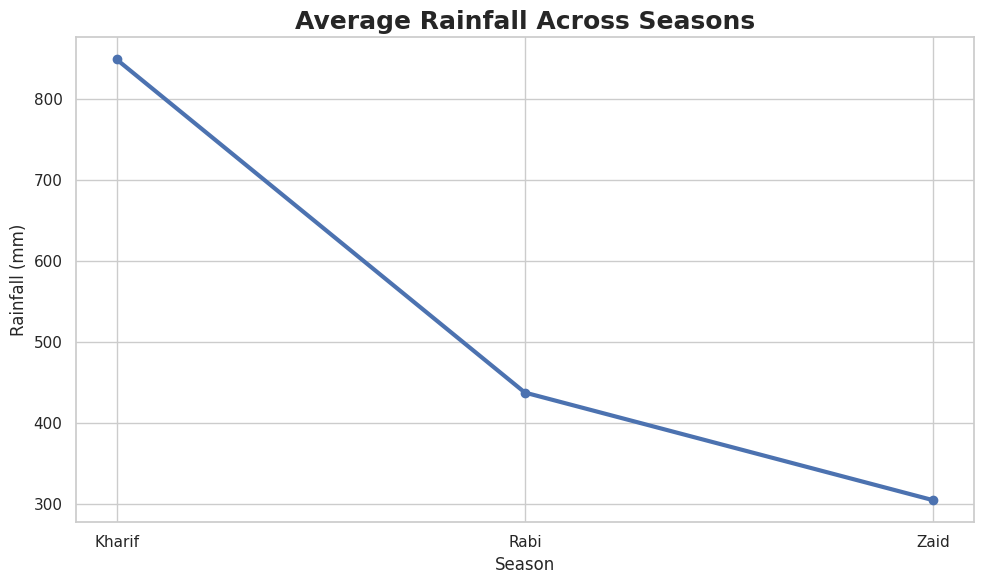

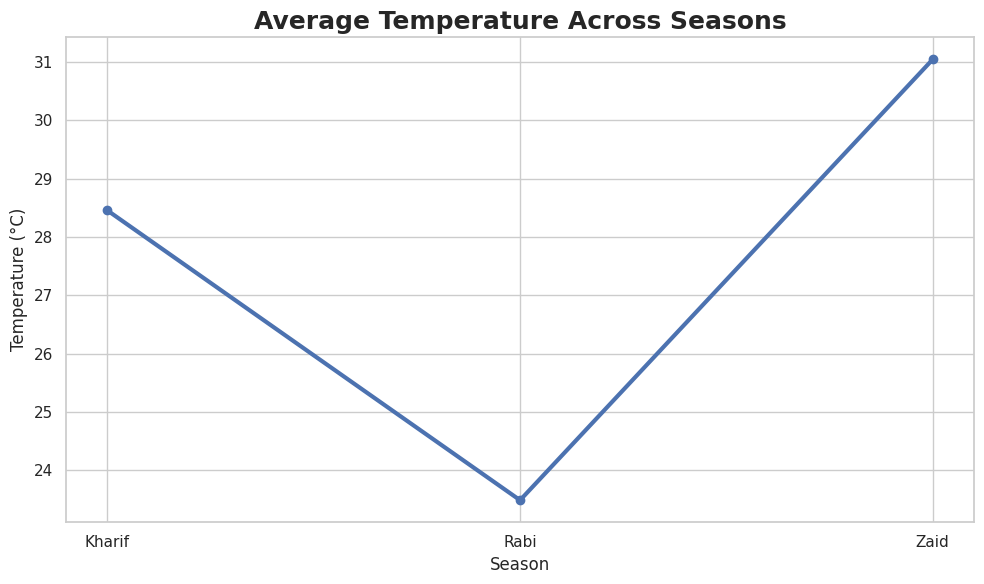

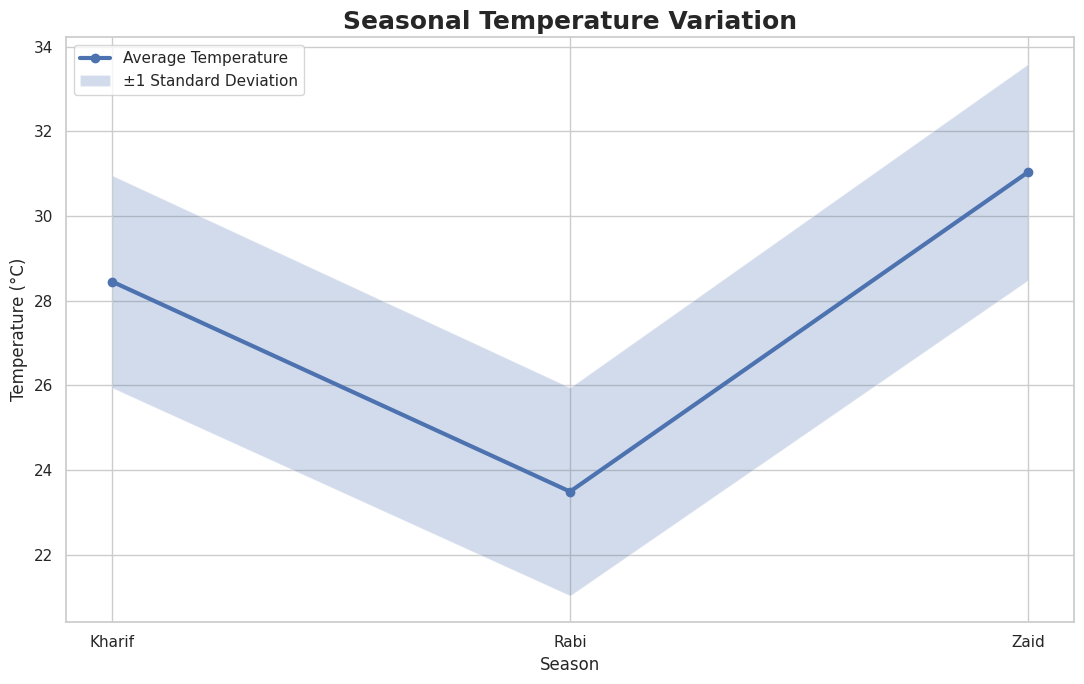

In [34]:
print("\n" + "=" * 70)
print(" ENVIRONMENTAL CONDITIONS")
print("=" * 70)

environment = (
    df_clean.groupby("Season")[
        [
            "Rainfall_mm",
            "Avg_Temperature_C",
            "Humidity_pct",
            "Sunlight_Hours_Day"
        ]
    ]
    .mean()
    .reindex(season_order)
)

display(environment.round(2))
plt.figure(figsize=(10, 6))

plt.plot(
    environment.index,
    environment["Rainfall_mm"],
    marker="o",
    linewidth=3
)

plt.title(
    "Average Rainfall Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    environment.index,
    environment["Avg_Temperature_C"],
    marker="o",
    linewidth=3
)

plt.title(
    "Average Temperature Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


# RIBBON CHART FOR TEMPERATURE
temp_mean = (
    df_clean.groupby("Season")
    ["Avg_Temperature_C"]
    .mean()
    .reindex(season_order)
)

temp_std = (
    df_clean.groupby("Season")
    ["Avg_Temperature_C"]
    .std()
    .reindex(season_order)
)
x = np.arange(len(season_order))

plt.figure(figsize=(11, 7))

plt.plot(
    x,
    temp_mean.values,
    marker="o",
    linewidth=3,
    label="Average Temperature"
)

plt.fill_between(
    x,
    temp_mean.values - temp_std.values,
    temp_mean.values + temp_std.values,
    alpha=0.25,
    label="±1 Standard Deviation"
)
plt.xticks(
    x,
    season_order
)

plt.title(
    "Seasonal Temperature Variation",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()
plt.show()


**CROP PERFORMANCE**


 CROP PERFORMANCE


,Average Yield
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


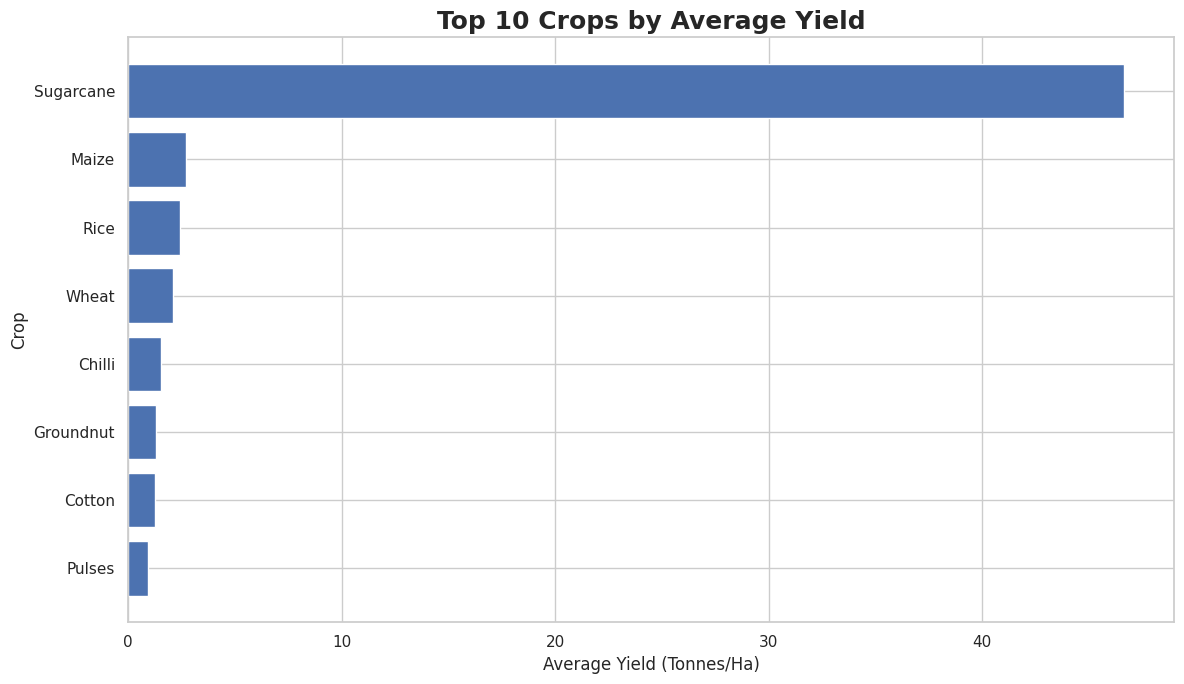

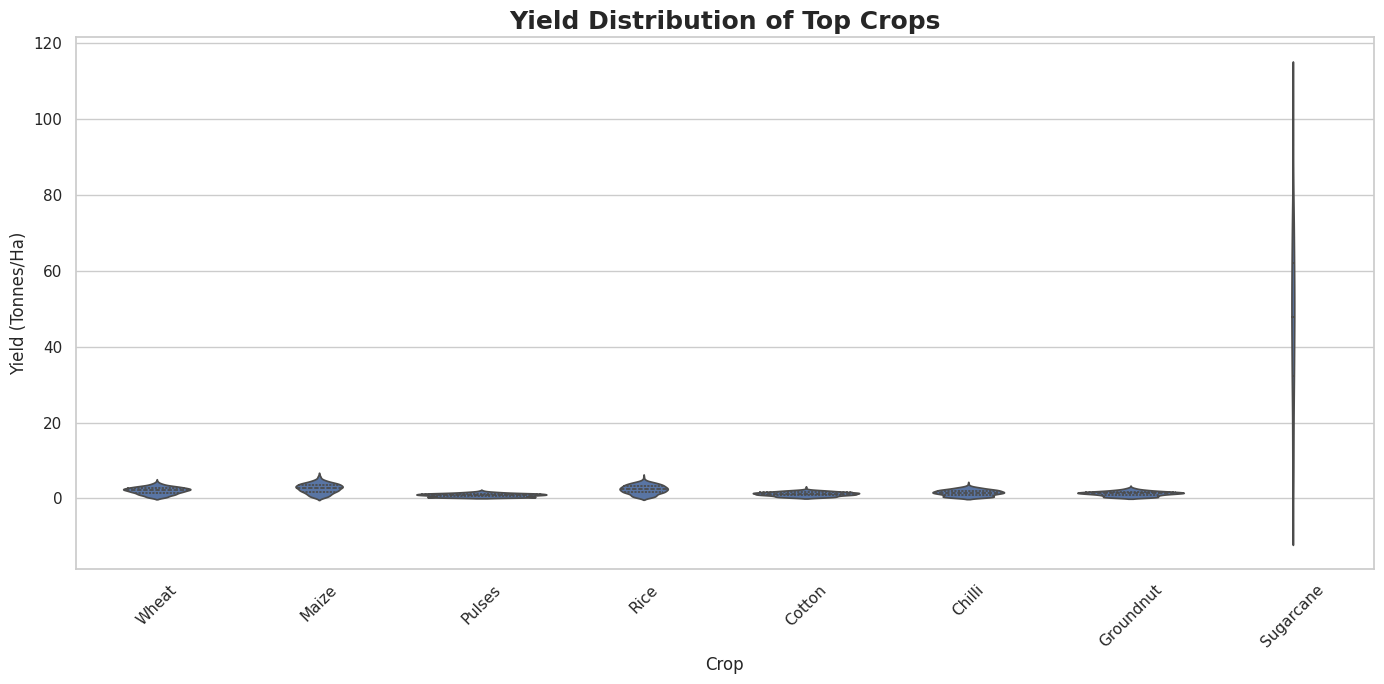

In [35]:
print("\n" + "=" * 70)
print(" CROP PERFORMANCE")
print("=" * 70)

crop_yield = (
    df_clean.groupby("Crop")
    ["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(
    crop_yield.round(2).to_frame(
        "Average Yield"
    )
)
plt.figure(figsize=(12, 7))

plt.barh(
    crop_yield.index[::-1],
    crop_yield.values[::-1]
)

plt.title(
    "Top 10 Crops by Average Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()
# VIOLIN PLOT
top_crops = crop_yield.index

crop_data = df_clean[
    df_clean["Crop"].isin(top_crops)
]

plt.figure(figsize=(14, 7))

sns.violinplot(
    data=crop_data,
    x="Crop",
    y="Yield_Tonnes_Ha",
    inner="quartile"
)
plt.title(
    "Yield Distribution of Top Crops",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



**REGIONAL PERFORMANCE**


 REGIONAL PERFORMANCE


,Average Yield
State,
Punjab,6.12
Karnataka,5.69
Gujarat,5.66
Telangana,5.04
Maharashtra,5.02
Madhya Pradesh,4.99
Tamil Nadu,4.88
Andhra Pradesh,4.63


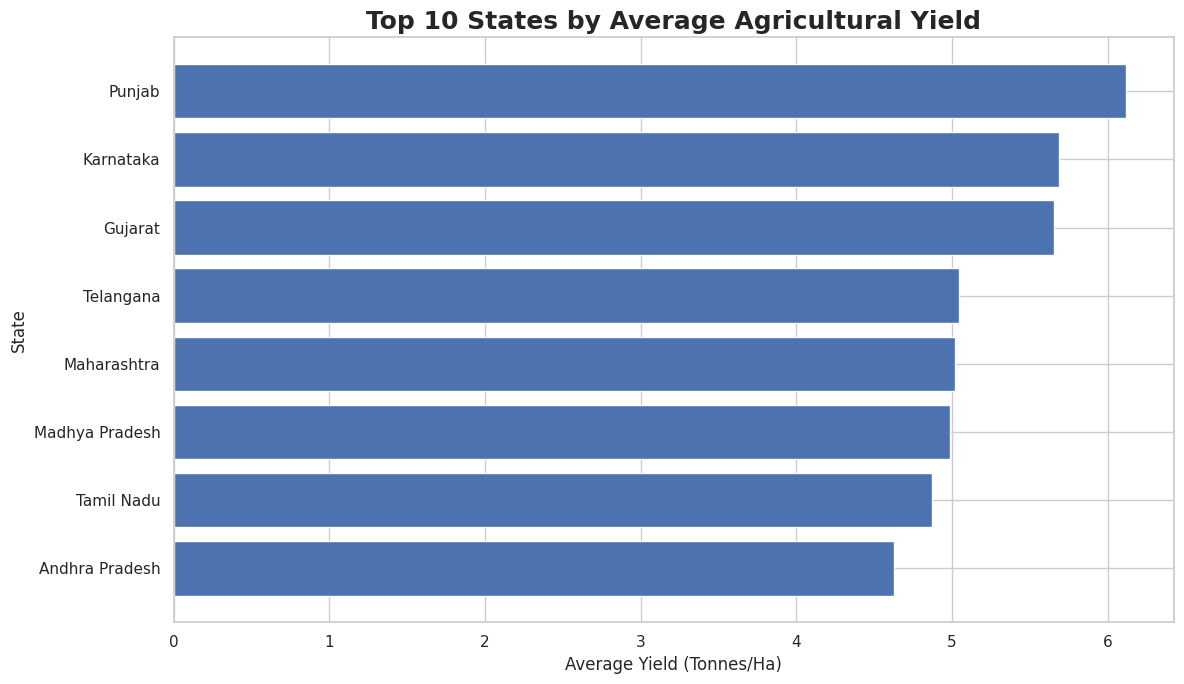

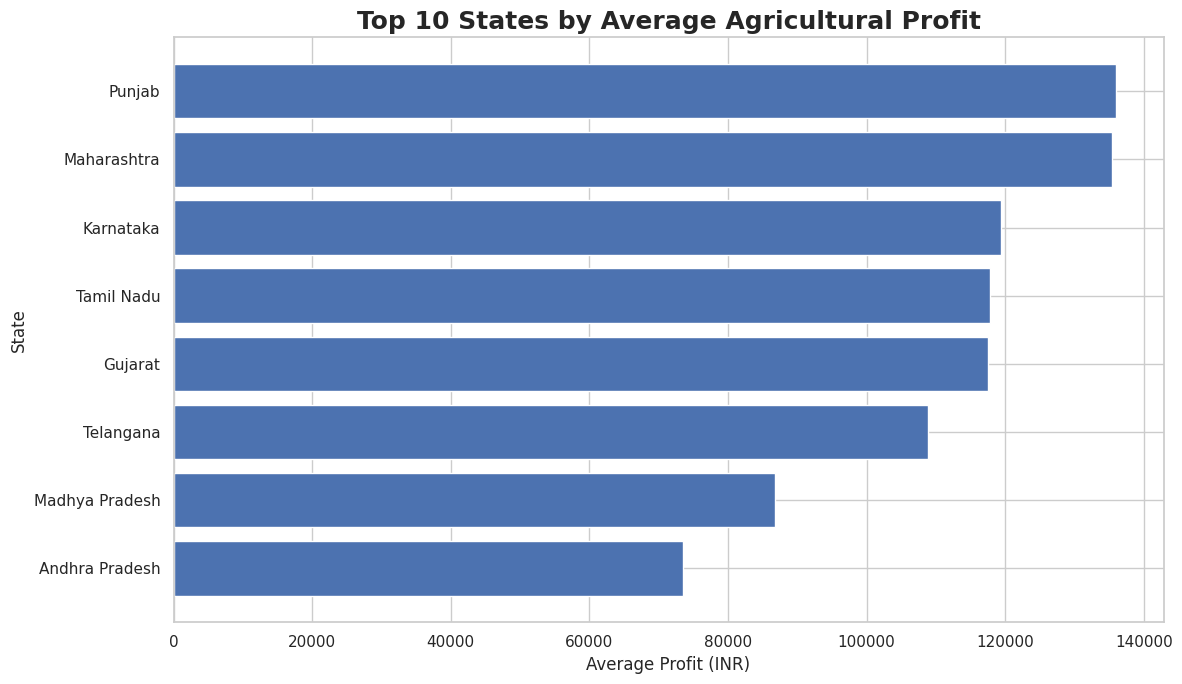

In [36]:
print("\n" + "=" * 70)
print(" REGIONAL PERFORMANCE")
print("=" * 70)

state_yield = (
    df_clean.groupby("State")
    ["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(
    state_yield.round(2).to_frame(
        "Average Yield"
    )
)
plt.figure(figsize=(12, 7))

plt.barh(
    state_yield.index[::-1],
    state_yield.values[::-1]
)

plt.title(
    "Top 10 States by Average Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

# STATE PROFIT
state_profit = (
    df_clean.groupby("State")
    ["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    state_profit.index[::-1],
    state_profit.values[::-1]
)

plt.title(
    "Top 10 States by Average Agricultural Profit",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()


**ENVIRONMENTAL RELATIONSHIPS**


 ENVIRONMENTAL RELATIONSHIPS


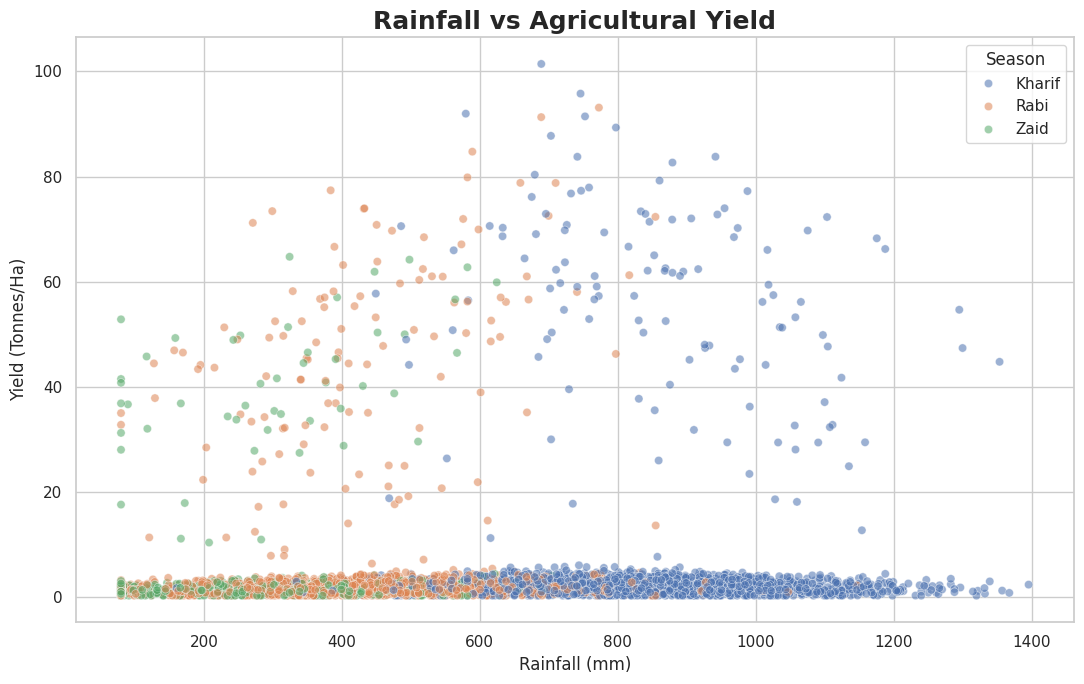

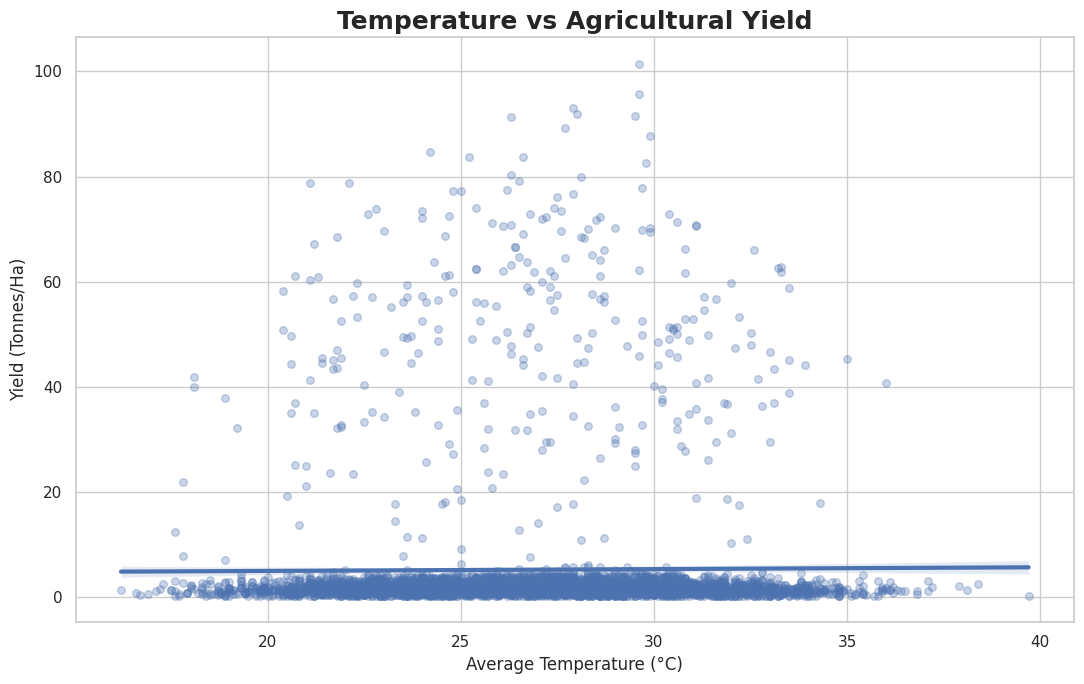

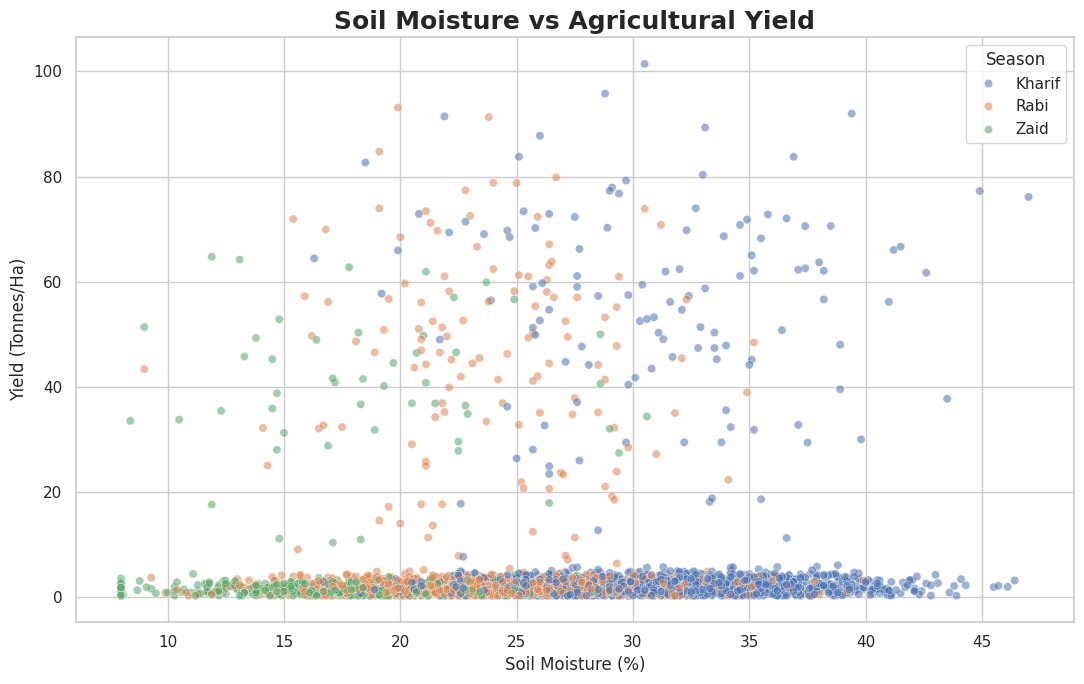

In [37]:
print("\n" + "=" * 70)
print(" ENVIRONMENTAL RELATIONSHIPS")
print("=" * 70)


# RAINFALL VS YIELD
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.55
)

plt.title(
    "Rainfall vs Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()


# TEMPERATURE VS YIELD
plt.figure(figsize=(11, 7))

sns.regplot(
    data=df_clean,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
     scatter_kws={
        "alpha": 0.3,
        "s": 30
    },
    line_kws={
        "linewidth": 3
    }
)

plt.title(
    "Temperature vs Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

# SOIL MOISTURE VS YIELD
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.55
)

plt.title(
    "Soil Moisture vs Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

**WATER EFFICIENCY ANALYSIS**


 WATER EFFICIENCY ANALYSIS
Water Efficiency vs Yield Correlation: 0.913


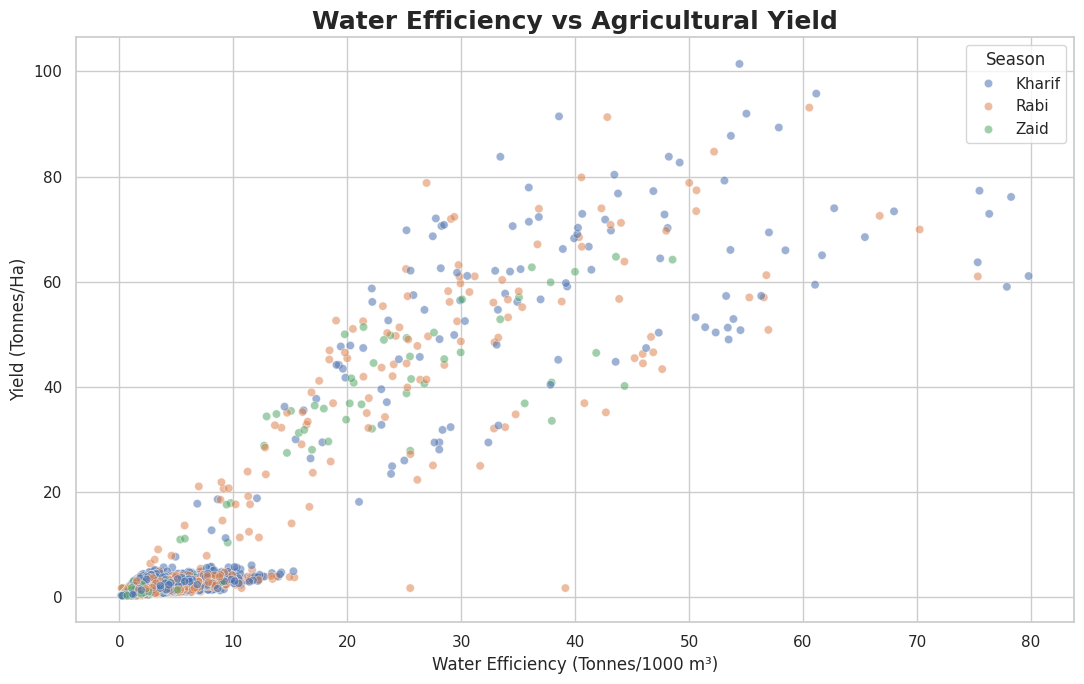

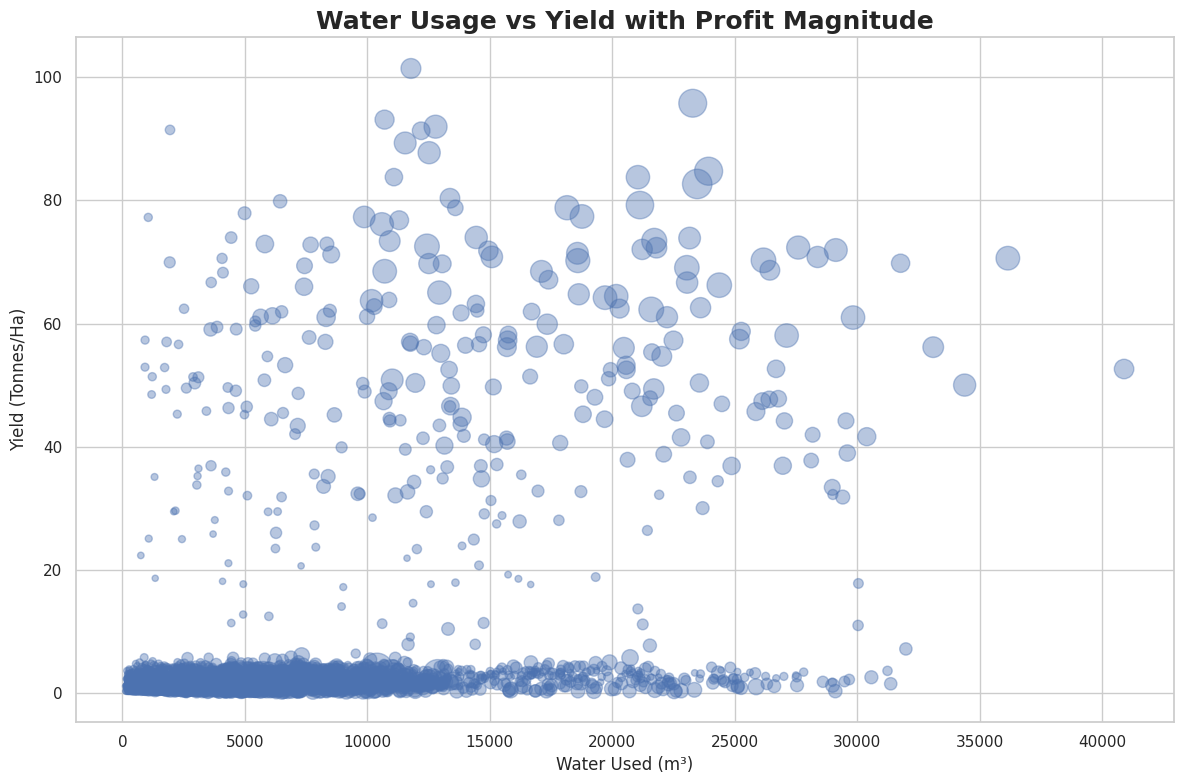

In [38]:
print("\n" + "=" * 70)
print(" WATER EFFICIENCY ANALYSIS")
print("=" * 70)

water_corr = df_clean[
    [
        "Water_Efficiency_t_per_1000m3",
        "Yield_Tonnes_Ha"
    ]
].corr().iloc[0, 1]

print(
    "Water Efficiency vs Yield Correlation:",
    round(water_corr, 3)
)
# SCATTER
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="Water_Efficiency_t_per_1000m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.55
)

plt.title(
    "Water Efficiency vs Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Water Efficiency (Tonnes/1000 m³)"
)
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()


# BUBBLE PLOT
bubble_data = df_clean.copy()

bubble_size = (
    bubble_data["Profit_INR"]
    .abs()
)

bubble_size = (
    bubble_size /
    bubble_size.max()
) * 500 + 20
plt.figure(figsize=(12, 8))

plt.scatter(
    bubble_data["Water_Used_m3"],
    bubble_data["Yield_Tonnes_Ha"],
    s=bubble_size,
    alpha=0.4
)

plt.title(
    "Water Usage vs Yield with Profit Magnitude",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

**STATISTICAL ANALYSIS**


 STATISTICAL ANALYSIS

YIELD ANOVA
F-statistic: 1.5439
P-value: 0.21367813841792296
Seasonal yield differences are not statistically significant.

PROFIT ANOVA
F-statistic: 34.2918
P-value: 1.7124156677360182e-15
Seasonal profit differences are statistically significant.

Correlation with Yield:


,Correlation
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Rainfall_mm,0.030951
Humidity_pct,0.012297
Soil_Moisture_pct,0.010999
Avg_Temperature_C,0.009996
Fertilizer_kg_ha,0.000018
Pesticide_Litre_ha,-0.007779


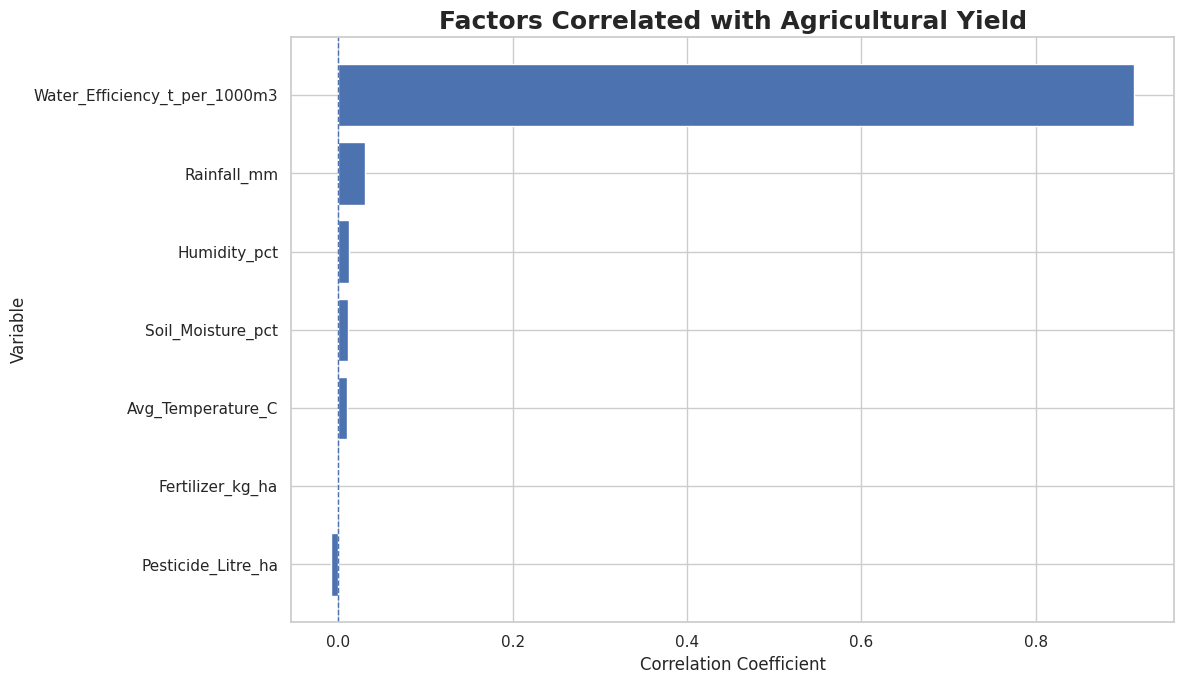

In [39]:
print("\n" + "=" * 70)
print(" STATISTICAL ANALYSIS")
print("=" * 70)


# YIELD ANOVA
yield_groups = [
    df_clean[
        df_clean["Season"] == season
    ]["Yield_Tonnes_Ha"]
    for season in season_order
]

yield_anova = f_oneway(
    *yield_groups
)


print("\nYIELD ANOVA")
print(
    "F-statistic:",
    round(yield_anova.statistic, 4)
)

print(
    "P-value:",
    yield_anova.pvalue
)

if yield_anova.pvalue < 0.05:
    print(
        "Seasonal yield differences are "
        "statistically significant."
    )
else:
   print(
        "Seasonal yield differences are "
        "not statistically significant."
    )


# PROFIT ANOVA
profit_groups = [
    df_clean[
        df_clean["Season"] == season
    ]["Profit_INR"]
    for season in season_order
]

profit_anova = f_oneway(
    *profit_groups
)
print("\nPROFIT ANOVA")

print(
    "F-statistic:",
    round(profit_anova.statistic, 4)
)

print(
    "P-value:",
    profit_anova.pvalue
)

if profit_anova.pvalue < 0.05:
    print(
        "Seasonal profit differences are "
        "statistically significant."
    )
else: print(
        "Seasonal profit differences are "
        "not statistically significant."
    )


# CORRELATION TABLE
important_columns = [
    "Yield_Tonnes_Ha",
    "Water_Efficiency_t_per_1000m3",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]
correlation = (
    df_clean[important_columns]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

print("\nCorrelation with Yield:")

display(
    correlation.to_frame(
        "Correlation"
    )
)

# CORRELATION BAR GRAPH
correlation_plot = (
    correlation
    .drop("Yield_Tonnes_Ha")
    .sort_values()
)

plt.figure(figsize=(12, 7))

plt.barh(
    correlation_plot.index,
    correlation_plot.values
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)
plt.title(
    "Factors Correlated with Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

**OUTLIER AND UNUSUAL PATTERN ANALYSIS**


 OUTLIER AND UNUSUAL PATTERN ANALYSIS
Yield Lower Boundary: -1.62
Yield Upper Boundary: -1.62
Yield Upper Boundary: 5.5
Number of Yield Outliers: 302


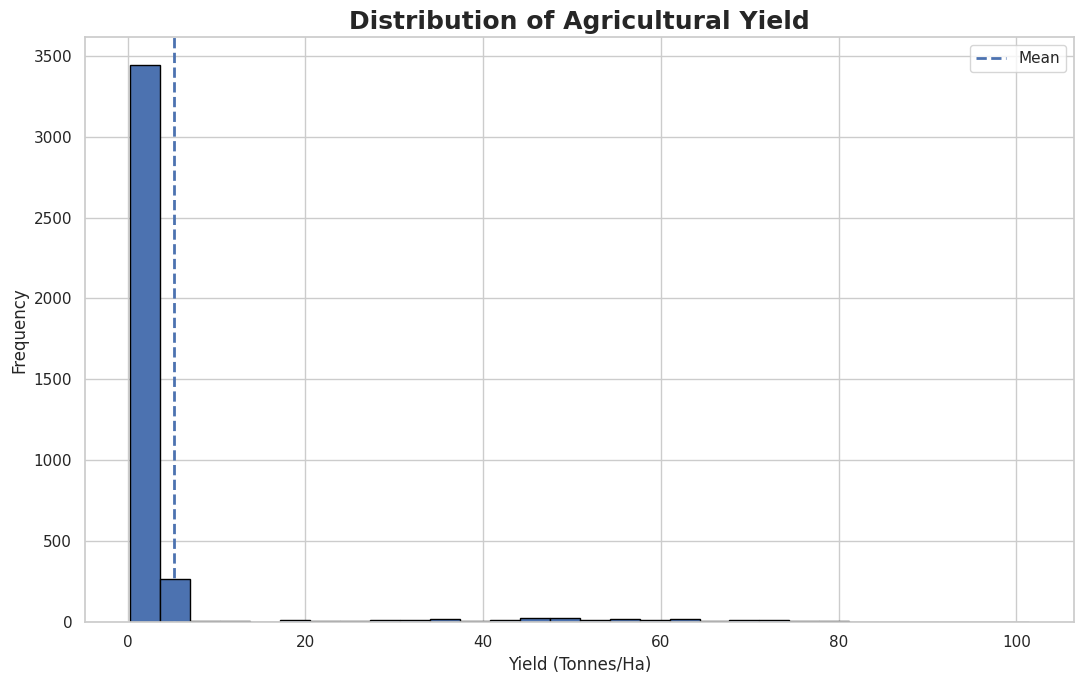

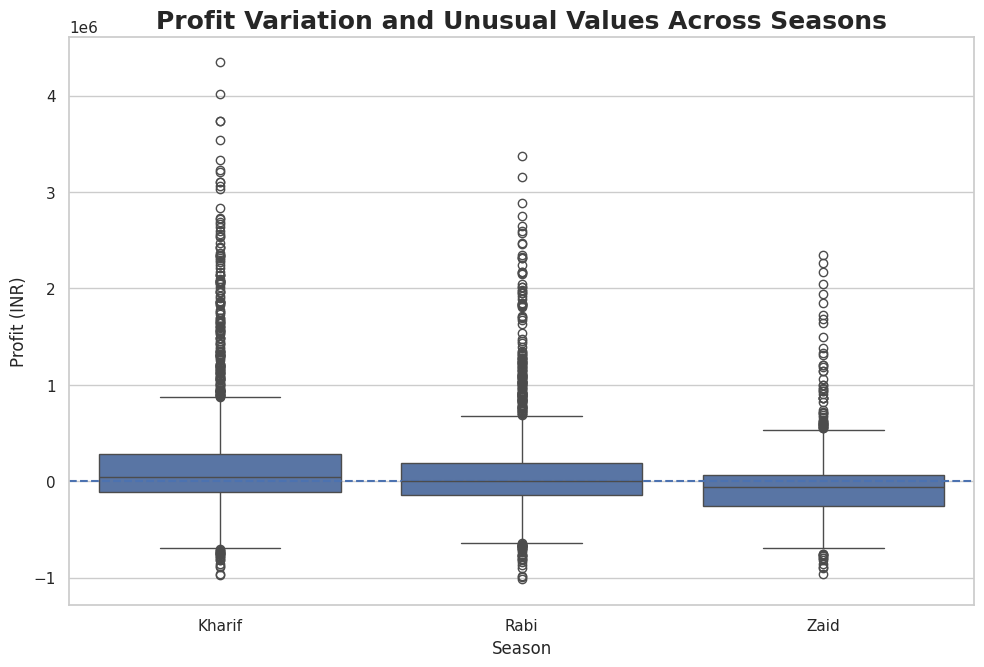

In [40]:
print("\n" + "=" * 70)
print(" OUTLIER AND UNUSUAL PATTERN ANALYSIS")
print("=" * 70)


# IQR FUNCTION
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
         (data[column] > upper)
    ]

    return outliers, lower, upper


yield_outliers, lower, upper = (
    detect_outliers(
        df_clean,
        "Yield_Tonnes_Ha"
    )
)

print(
    "Yield Lower Boundary:",
    round(lower, 2)
)

print(
    "Yield Upper Boundary:",
     round(lower, 2)
)

print(
    "Yield Upper Boundary:",
    round(upper, 2)
)

print(
    "Number of Yield Outliers:",
    len(yield_outliers)
)


# HISTOGRAM
plt.figure(figsize=(11, 7))
plt.hist(
    df_clean["Yield_Tonnes_Ha"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    df_clean["Yield_Tonnes_Ha"].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.title(
    "Distribution of Agricultural Yield",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()


# BOX PLOT
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Profit_INR",
    order=season_order
)
plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Profit Variation and Unusual Values Across Seasons",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


**FINAL INSIGHTS, CONCLUSIONS AND RECOMMENDATIONS**


 FINAL INSIGHTS AND CONCLUSIONS

MASTER SEASONAL PERFORMANCE TABLE


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm,Avg_Temperature_C
Season,,,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47,849.20,28.45
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48,437.62,23.49
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22,304.65,31.04



KEY FINDINGS
----------------------------------------------------------------------
1. Highest average yield: Kharif
2. Highest average profit: Kharif
3. Lowest average profit: Zaid
4. Highest water usage: Zaid
5. Highest water efficiency: Kharif
6. Highest disease/pest risk: Kharif
7. Water efficiency-yield correlation: 0.913
8. Yield ANOVA p-value: 0.213678
9. Profit ANOVA p-value: 0.000000


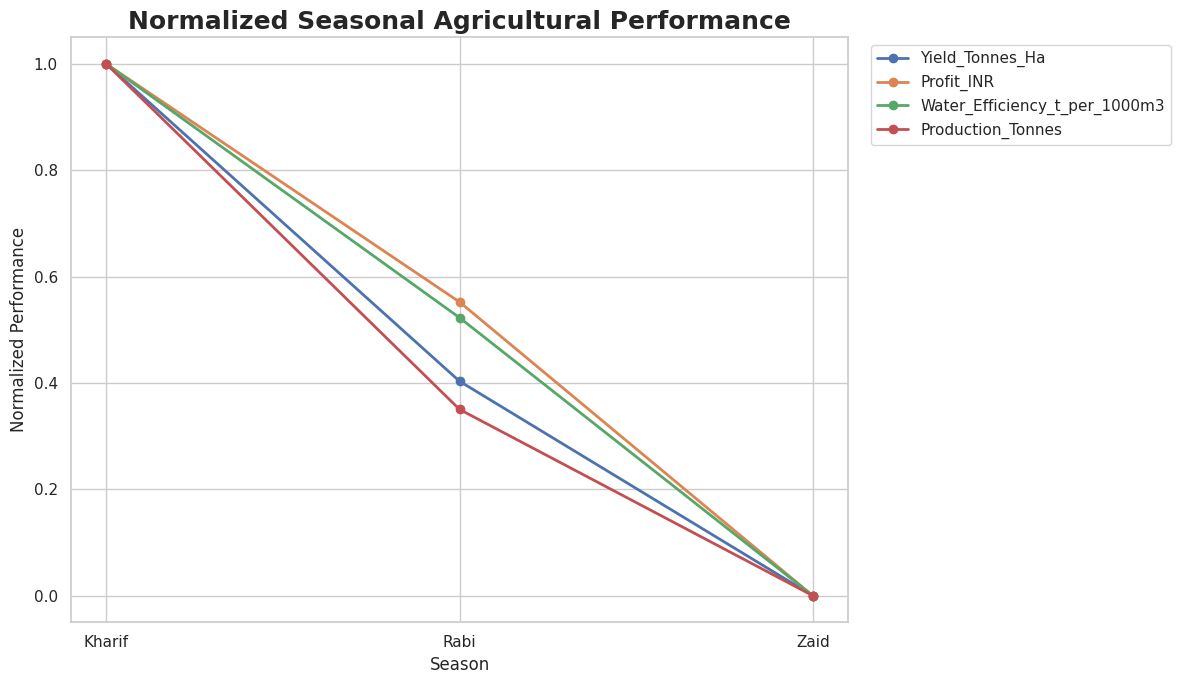


FINAL PROJECT CONCLUSION

The Seasonal Agriculture Performance Analysis examined
agricultural activities across Kharif, Rabi and Zaid seasons.

The analysis included data exploration, data cleaning,
seasonal comparisons, crop analysis, regional analysis,
resource utilization, environmental analysis, economic
performance, correlation analysis, statistical testing and
outlier detection.
The analysis identified Kharif as the season
with the highest average yield.

Kharif recorded the highest average profit,
while Zaid recorded the lowest average
profit.

The relationship between water efficiency and yield was
measured using Pearson correlation, producing a correlation
coefficient of 0.913.

ANOVA was applied to examine whether seasonal differences
in yield and profit were statistically significant.

The findings can support evidence-based seasonal planning,
resource management, irrigation planning, crop selection
and agricultural performance monitoring.
The conclusions are based on the a

In [26]:
print("\n" + "=" * 70)
print(" FINAL INSIGHTS AND CONCLUSIONS")
print("=" * 70)


# MASTER SUMMARY
season_summary = (
    df_clean.groupby("Season")
    .agg({
        "Yield_Tonnes_Ha": "mean",
        "Production_Tonnes": "mean",
        "Revenue_INR": "mean",
        "Total_Cost_INR": "mean",
        "Profit_INR": "mean",
        "Water_Used_m3": "mean",
         "Water_Efficiency_t_per_1000m3": "mean",
        "Disease_Pest_Risk_pct": "mean",
        "Rainfall_mm": "mean",
        "Avg_Temperature_C": "mean"
    })
    .reindex(season_order)
)

print("\nMASTER SEASONAL PERFORMANCE TABLE")

display(
    season_summary.round(2)
)
# AUTOMATIC FINDINGS

highest_yield_season = (
    season_summary[
        "Yield_Tonnes_Ha"
    ].idxmax()
)

highest_profit_season = (
    season_summary[
        "Profit_INR"
    ].idxmax()
)

lowest_profit_season = (
    season_summary[
        "Profit_INR"
    ].idxmin()
    )

highest_water_season = (
    season_summary[
        "Water_Used_m3"
    ].idxmax()
)

highest_efficiency_season = (
    season_summary[
        "Water_Efficiency_t_per_1000m3"
    ].idxmax()
)

highest_risk_season = (
    season_summary[
        "Disease_Pest_Risk_pct"
    ].idxmax()
)
print("\nKEY FINDINGS")
print("-" * 70)

print(
    f"1. Highest average yield: "
    f"{highest_yield_season}"
)

print(
    f"2. Highest average profit: "
    f"{highest_profit_season}"
)

print(
    f"3. Lowest average profit: "
    f"{lowest_profit_season}"
)
print(
    f"4. Highest water usage: "
    f"{highest_water_season}"
)

print(
    f"5. Highest water efficiency: "
    f"{highest_efficiency_season}"
)

print(
    f"6. Highest disease/pest risk: "
    f"{highest_risk_season}"
)

print(
    f"7. Water efficiency-yield correlation: "
    f"{water_corr:.3f}"
)
print(
    f"8. Yield ANOVA p-value: "
    f"{yield_anova.pvalue:.6f}"
)

print(
    f"9. Profit ANOVA p-value: "
    f"{profit_anova.pvalue:.6f}"
)


# FINAL PERFORMANCE CHART
plt.figure(figsize=(12, 7))

normalized = season_summary[
    [
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3",
        "Production_Tonnes"
         ]
].copy()

normalized = (
    normalized - normalized.min()
) / (
    normalized.max() - normalized.min()
)

for metric in normalized.columns:

    plt.plot(
        season_order,
        normalized.loc[
            season_order,
            metric
        ],
         marker="o",
        linewidth=2,
        label=metric
    )

plt.title(
    "Normalized Seasonal Agricultural Performance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Normalized Performance")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


# FINAL CONCLUSION
print("\n" + "=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print(f"""
The Seasonal Agriculture Performance Analysis examined
agricultural activities across Kharif, Rabi and Zaid seasons.

The analysis included data exploration, data cleaning,
seasonal comparisons, crop analysis, regional analysis,
resource utilization, environmental analysis, economic
performance, correlation analysis, statistical testing and
outlier detection.
The analysis identified {highest_yield_season} as the season
with the highest average yield.

{highest_profit_season} recorded the highest average profit,
while {lowest_profit_season} recorded the lowest average
profit.

The relationship between water efficiency and yield was
measured using Pearson correlation, producing a correlation
coefficient of {water_corr:.3f}.

ANOVA was applied to examine whether seasonal differences
in yield and profit were statistically significant.

The findings can support evidence-based seasonal planning,
resource management, irrigation planning, crop selection
and agricultural performance monitoring.
The conclusions are based on the available dataset and
describe statistical patterns rather than proving causal
relationships.
""")

In [27]:
df_clean.to_csv(
    "/content/seasonal_agriculture_cleaned.csv",
    index=False
)

season_summary.to_csv(
    "/content/seasonal_performance_summary.csv"
)

correlation.to_csv(
    "/content/yield_correlation_results.csv"
)

print("\nFiles saved successfully:")
print("/content/seasonal_agriculture_cleaned.csv")
print("/content/seasonal_performance_summary.csv")
print("/content/yield_correlation_results.csv")

print("\n" + "=" * 70)
print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS COMPLETED")
print("=" * 70)


Files saved successfully:
/content/seasonal_agriculture_cleaned.csv
/content/seasonal_performance_summary.csv
/content/yield_correlation_results.csv

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS COMPLETED
